# Finite-Difference Playground

## Author: Zach Etienne

This notebook adapts the NRPy finite-difference tutorial material and the
active finite-difference helper APIs.

To run the whole notebook, click the `>>` toolbar button and choose
**Restart Kernel and Run All Cells...**.

This notebook validates one fourth-order centered second-derivative stencil
and then inspects the complete generated C update and helper function for the
same stencil.

**Notebook Status:** Validated

**Validation Notes:** The validation checks compare the stencil against an
exact polynomial derivative, then confirm that generated BHaH C code contains
the expected memory reads, helper function, and zero symbolic residual.

Navigation: [Index](../index.ipynb) |
Previous: [Boundary Conditions and Convergence](boundary_conditions_and_convergence.ipynb) |
Next: [Wave Equation and C Code Generation](../3-wave_equation/wave_equation_and_c_codegen.ipynb)

# Table of Contents

1. [Required Reading and Source Links](#Required-Reading-and-Source-Links)
1. [Words for This Notebook](#Words-for-This-Notebook)
1. [Step 1](#Step-1:-State-the-Fourth-Order-Centered-Stencil): State the stencil.
1. [Step 2](#Step-2:-Configure-NRPy-Finite-Difference-State): Configure NRPy state.
1. [Step 3](#Step-3:-Ask-NRPy-for-Stencil-Weights): Print weights.
1. [Step 4](#Step-4:-Plot-Weights-by-Grid-Offset): Plot weights.
1. [Step 5](#Step-5:-Validate-the-Stencil-on-a-Polynomial): Validate the stencil.
1. [Step 6](#Step-6:-Generate-the-C-Laplacian-Assignment): Generate C.
1. [Validation Check](#Validation-Check): Validate generated C metadata.
1. [What next?](#What-next?)

# Required Reading and Source Links
### [Back to [top](#Table-of-Contents)]

Required reading:

- [Finite Differences](../1-intro/finite_difference.ipynb): useful background.
  This notebook also defines each finite-difference term it uses.

Installed source modules used by this lesson:

- `nrpy.finite_difference`: stencil coefficients, generated FD helper
  metadata, and FD function registry.
- `nrpy.grid`: scalar gridfunction registration.
- `nrpy.indexedexp`: symbolic derivative placeholder construction.
- `nrpy.c_codegen`: support machinery used here only to expose the generated
  finite-difference C artifact.
- `nrpy.params`: infrastructure and finite-difference order parameters.

# Words for This Notebook
### [Back to [top](#Table-of-Contents)]

- **Stencil:** A fixed weighted sum of nearby grid values.
- **Centered stencil:** A stencil with symmetric offsets around the center
  point, such as `-2, -1, 0, +1, +2`.
- **Finite-difference order:** The leading power of grid spacing in the
  truncation error; fourth order means the leading error scales like
  `Delta x^4`.
- **Stencil width:** The number of grid points read by the stencil.
- **Grid offset:** An integer displacement from the center grid point.
- **Derivative symbol:** A symbolic placeholder that tells NRPy which finite
  difference operator to generate.
- **`dDD00`:** NRPy's operator name for the second derivative with respect to
  coordinate direction 0 twice.
- **`uu_dDD[0][0]`:** The symbolic second derivative of scalar gridfunction
  `uu` in direction 0.
- **Grid field:** A value stored at every grid point.
- **BHaH memory convention:** Generated C reads gridfunction data through
  `in_gfs[IDX4(...)]` memory-access strings.

# Step 1: State the Fourth-Order Centered Stencil
### [Back to [top](#Table-of-Contents)]

The fourth-order centered second-derivative stencil is

$$
\partial_x^2 u_i \approx
\frac{-u_{i-2} + 16u_{i-1} - 30u_i + 16u_{i+1} - u_{i+2}}
{12 \Delta x^2}.
$$

The polynomial `x**4` has exact second derivative `12*x**2`. The stencil
should reproduce that derivative exactly at the sample point used below.

# Step 2: Configure NRPy Finite-Difference State
### [Back to [top](#Table-of-Contents)]

This source-provenance check must resolve NRPy through the pip-installed
package. It raises immediately if a local cloned `nrpy/` directory shadows the
installed package.

In [1]:
from pathlib import Path
import importlib.util
import logging


NOTEBOOK_DIR = Path.cwd().resolve()
FORBIDDEN_SOURCE_ROOTS = [NOTEBOOK_DIR.parent / "nrpy"]
logging.getLogger("matplotlib").setLevel(logging.WARNING)


def installed_source_path(module_name):
    spec = importlib.util.find_spec(module_name)
    if spec is None or spec.origin is None:
        raise RuntimeError(f"Could not locate installed module: {module_name}")
    path = Path(spec.origin).resolve()
    for root in FORBIDDEN_SOURCE_ROOTS:
        if not root.exists():
            continue
        try:
            path.relative_to(root.resolve())
        except ValueError:
            continue
        raise RuntimeError(f"{module_name} resolved to cloned source: {path}")
    return path


source_modules = [
    "nrpy.c_codegen",
    "nrpy.finite_difference",
    "nrpy.grid",
    "nrpy.indexedexp",
    "nrpy.params",
]
print("installed NRPy source paths:")
for module_name in source_modules:
    print(module_name, "->", installed_source_path(module_name))

installed NRPy source paths:
nrpy.c_codegen -> /virt/lib/python3.12/site-packages/nrpy/c_codegen.py
nrpy.finite_difference -> /virt/lib/python3.12/site-packages/nrpy/finite_difference.py
nrpy.grid -> /virt/lib/python3.12/site-packages/nrpy/grid.py
nrpy.indexedexp -> /virt/lib/python3.12/site-packages/nrpy/indexedexp.py
nrpy.params -> /virt/lib/python3.12/site-packages/nrpy/params.py


These setup cells import the tools, clear tutorial-owned state, and set BHaH
infrastructure with fourth-order finite differences.

In [2]:
import sympy as sp

import nrpy.c_codegen as ccg
import nrpy.finite_difference as fd
import nrpy.grid as gri
import nrpy.indexedexp as ixp
import nrpy.params as par

In [3]:
gri.glb_gridfcs_dict.pop("uu", None)
for name in list(fd.FDFunctions_dict):
    if name.startswith("fdD"):
        fd.FDFunctions_dict.pop(name, None)

par.set_parval_from_str("Infrastructure", "BHaH")
par.set_parval_from_str("finite_difference::fd_order", 4)

print("infrastructure:", par.parval_from_str("Infrastructure"))
print("finite-difference order:", par.parval_from_str("finite_difference::fd_order"))
print("tutorial grid field reset:", "uu" not in gri.glb_gridfcs_dict)

infrastructure: BHaH
finite-difference order: 4
tutorial grid field reset: True


# Step 3: Ask NRPy for Stencil Weights
### [Back to [top](#Table-of-Contents)]

The printed coefficients should match the formula in Step 1. A fourth-order
centered second derivative uses two neighbors on each side of the center.

In [4]:
coeffs, stencil = fd.compute_fdcoeffs_fdstencl("dDD00", 4)
offset_weight_pairs = [(point[0], coeff) for coeff, point in zip(coeffs, stencil)]

print("stencil weights:")
for offset, coeff in offset_weight_pairs:
    print(offset, coeff)

stencil weights:
-2 -1/12
-1 4/3
0 -5/2
1 4/3
2 -1/12


# Step 4: Plot Weights by Grid Offset
### [Back to [top](#Table-of-Contents)]

The plot shows the sign pattern and symmetry of the centered second
derivative: the center point is compared against nearby points on both sides.

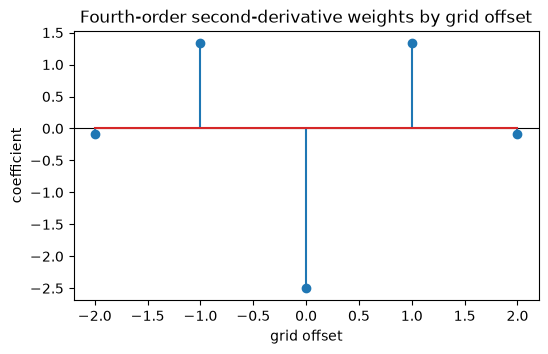

In [5]:
import matplotlib.pyplot as plt

offsets = [point[0] for point in stencil]
numeric_coeffs = [float(coeff) for coeff in coeffs]

plt.figure(figsize=(6, 3.5))
plt.axhline(0.0, color="black", linewidth=0.8)
plt.stem(offsets, numeric_coeffs)
plt.xlabel("grid offset")
plt.ylabel("coefficient")
plt.title("Fourth-order second-derivative weights by grid offset")
plt.show()

# Step 5: Validate the Stencil on a Polynomial
### [Back to [top](#Table-of-Contents)]

The trusted result is the hand-written coefficient map and the exact
derivative of `x**4`. The new calculation applies NRPy's coefficients at
`x0 = 3/2` with `dx = 1/5`.

In [6]:
expected_offset_weight_pairs = [
    (-2, -sp.Rational(1, 12)),
    (-1, sp.Rational(4, 3)),
    (0, -sp.Rational(5, 2)),
    (1, sp.Rational(4, 3)),
    (2, -sp.Rational(1, 12)),
]
if offset_weight_pairs != expected_offset_weight_pairs:
    raise RuntimeError(f"Unexpected stencil mapping: {offset_weight_pairs}")

x = sp.Symbol("x")
x0 = sp.Rational(3, 2)
dx_sample = sp.Rational(1, 5)
stencil_value = sp.simplify(
    sum(
        coeffs[i] * (x0 + stencil[i][0] * dx_sample) ** 4 / dx_sample**2
        for i in range(len(coeffs))
    )
)
exact_value = sp.diff(x**4, x, 2).subs(x, x0)
stencil_residual = sp.simplify(stencil_value - exact_value)

print("trusted coefficient map:", expected_offset_weight_pairs)
print("stencil value:", stencil_value)
print("exact value:", exact_value)
print("stencil residual:", stencil_residual)
if stencil_residual != 0:
    raise RuntimeError("Expected the stencil residual to vanish.")
print("PASS: stencil matches exact polynomial derivative")

trusted coefficient map: [(-2, -1/12), (-1, 4/3), (0, -5/2), (1, 4/3), (2, -1/12)]
stencil value: 27
exact value: 27
stencil residual: 0
PASS: stencil matches exact polynomial derivative


# Step 6: Generate the C Laplacian Assignment
### [Back to [top](#Table-of-Contents)]

The scalar gridfunction `uu` belongs to the `EVOL` group, has rank 0, and has
no component index because the base name and full component name are both
`uu`. Generated BHaH code will read its values from `in_gfs` with `IDX4(...)`
memory access.

The first generated-code cell registers the scalar field and asks `c_codegen`
to expose the C update for `uu_dDD[0][0]`.

In [7]:
uu_symbol = gri.register_gridfunctions("uu", group="EVOL")[0]
uu_dDD = ixp.declarerank2("uu_dDD", symmetry="sym01")
generated_laplacian = ccg.c_codegen(
    uu_dDD[0][0],
    "laplacian_x0",
    include_braces=False,
    verbose=False,
    enable_fd_codegen=True,
    enable_fd_functions=True,
)
helper_code = fd.construct_FD_functions_prefunc()
fd_function = fd.FDFunctions_dict.get("dDD00")
uu_metadata = gri.glb_gridfcs_dict["uu"]

print("registered gridfunction symbol:", uu_symbol)
print("registered gridfunction:", uu_metadata.name)
print("group:", uu_metadata.group)
print("rank:", uu_metadata.rank)
print("dimension:", uu_metadata.dimension)
print("component naming: scalar base name is the full component name")

registered gridfunction symbol: uu
registered gridfunction: uu
group: EVOL
rank: 0
dimension: 3
component naming: scalar base name is the full component name


The metadata check ties the generated finite-difference helper back to the
trusted stencil. It prints the generated operator name, order, and symbolic
residual.

In [8]:
if fd_function is None:
    raise RuntimeError("Expected NRPy to register the dDD00 FD function.")
if fd_function.operator != "dDD00":
    raise RuntimeError("Expected generated operator dDD00.")
if fd_function.fd_order != 4:
    raise RuntimeError("Expected generated finite-difference order 4.")

fd_symbols = {str(symbol): symbol for symbol in fd_function.FDexpr.free_symbols}
expected_fdexpr = fd_symbols["invdxx0"] ** 2 * (
    -sp.Rational(5, 2) * fd_symbols["FDPROTO"]
    + sp.Rational(4, 3) * (fd_symbols["FDPROTO_i0m1"] + fd_symbols["FDPROTO_i0p1"])
    - sp.Rational(1, 12) * (fd_symbols["FDPROTO_i0m2"] + fd_symbols["FDPROTO_i0p2"])
)
actual_fdexpr = fd_function.FDexpr.xreplace(fd_function.symbol_to_Rational_dict)
fdexpr_residual = sp.simplify(actual_fdexpr - expected_fdexpr)

print("finite-difference helper:", fd_function.c_function_name)
print("finite-difference operator:", fd_function.operator)
print("finite-difference order:", fd_function.fd_order)
print("finite-difference expression residual:", fdexpr_residual)
if fdexpr_residual != 0:
    raise RuntimeError(f"Unexpected generated FD expression: {actual_fdexpr}")

finite-difference helper: fd_function_dDD00_fdorder4
finite-difference operator: dDD00
finite-difference order: 4
finite-difference expression residual: 0


Inspect the complete generated C update. Look for:

- `in_gfs[IDX4(...)]` BHaH memory reads;
- reads at offsets `i0-2`, `i0-1`, `i0`, `i0+1`, and `i0+2`;
- the helper call;
- the assignment target `laplacian_x0`.

In [9]:
print("complete generated C update:")
print(generated_laplacian)

complete generated C update:
/*
 * NRPy-Generated GF Access/FD Code, Step 1 of 2:
 * Read gridfunction(s) from main memory and compute FD stencils as needed.
 */
const REAL uu_i0m2 = in_gfs[IDX4(UUGF, i0-2, i1, i2)];
const REAL uu_i0m1 = in_gfs[IDX4(UUGF, i0-1, i1, i2)];
const REAL uu = in_gfs[IDX4(UUGF, i0, i1, i2)];
const REAL uu_i0p1 = in_gfs[IDX4(UUGF, i0+1, i1, i2)];
const REAL uu_i0p2 = in_gfs[IDX4(UUGF, i0+2, i1, i2)];
const REAL uu_dDD00 = fd_function_dDD00_fdorder4(uu,uu_i0m1,uu_i0m2,uu_i0p1,uu_i0p2,invdxx0);

/*
 * NRPy-Generated GF Access/FD Code, Step 2 of 2:
 * Evaluate SymPy expressions and write to main memory.
 */
laplacian_x0 = uu_dDD00;



Inspect the complete helper code. Look for:

- the helper signature;
- the fourth-order rational coefficients;
- the `invdxx0**2` scaling;
- the returned finite-difference result.

In [10]:
print("complete helper code:")
print(helper_code)

complete helper code:
/**
 * Finite difference function for operator dDD00, with FD accuracy order 4.
 */
static NO_INLINE REAL fd_function_dDD00_fdorder4(const REAL FDPROTO, const REAL FDPROTO_i0m1, const REAL FDPROTO_i0m2, const REAL FDPROTO_i0p1,
                                                 const REAL FDPROTO_i0p2, const REAL invdxx0) {
  static const REAL FDPart1_Rational_5_2 = 5.0 / 2.0;
  static const REAL FDPart1_Rational_1_12 = 1.0 / 12.0;
  static const REAL FDPart1_Rational_4_3 = 4.0 / 3.0;
  const REAL FD_result = ((invdxx0) * (invdxx0)) * (-FDPROTO * FDPart1_Rational_5_2 + FDPart1_Rational_1_12 * (-FDPROTO_i0m2 - FDPROTO_i0p2) +
                                                    FDPart1_Rational_4_3 * (FDPROTO_i0m1 + FDPROTO_i0p1));

  return FD_result;
} // END FUNCTION: fd_function_dDD00_fdorder4



# Validation Check
### [Back to [top](#Table-of-Contents)]

This final check confirms that the complete generated C artifact contains the
expected BHaH memory convention, stencil reads, helper function, and assignment
target.

In [11]:
required_generated_identifiers = [
    "in_gfs[IDX4(UUGF, i0-2, i1, i2)]",
    "in_gfs[IDX4(UUGF, i0+2, i1, i2)]",
    fd_function.c_function_name,
    "laplacian_x0",
]
combined_generated_code = generated_laplacian + "\n" + helper_code
missing_identifiers = [
    identifier
    for identifier in required_generated_identifiers
    if identifier not in combined_generated_code
]

print("trusted stencil coefficients:", expected_offset_weight_pairs)
print("generated operator:", fd_function.operator)
print("generated finite-difference order:", fd_function.fd_order)
print("symbolic expression residual:", fdexpr_residual)
print("expected memory convention: BHaH IDX4 reads from in_gfs")
print("required generated identifiers found:", not missing_identifiers)
if missing_identifiers:
    raise RuntimeError(f"Missing generated-code identifiers: {missing_identifiers}")
print("PASS: generated C update matches the validated stencil")

trusted stencil coefficients: [(-2, -1/12), (-1, 4/3), (0, -5/2), (1, 4/3), (2, -1/12)]
generated operator: dDD00
generated finite-difference order: 4
symbolic expression residual: 0
expected memory convention: BHaH IDX4 reads from in_gfs
required generated identifiers found: True
PASS: generated C update matches the validated stencil


# What next?
### [Back to [top](#Table-of-Contents)]

- [C Code Generation](../1-intro/c_codegen.ipynb)
- [Finite Differences](../1-intro/finite_difference.ipynb)
- [Wave Equation and C Code Generation](../3-wave_equation/wave_equation_and_c_codegen.ipynb)